# Is `cached-dataset/part_3` relative or absolute?

This notebook audits the cached `state [N, 7]` and `actions [N, 64, 7]` tensors before B0 retraining. It tests whether the action horizon contains absolute target states or normalized relative controller commands.

The analysis deliberately excludes the gripper from pose-error comparisons because its binary convention differs from the six continuous pose dimensions.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'cached-dataset' / 'part_3').is_dir():
            return candidate
    raise FileNotFoundError('Could not find cached-dataset/part_3')

REPO = find_repo_root()
CACHE = REPO / 'cached-dataset' / 'part_3'
SPLIT = 'train'
MAX_PACKS_PER_DATASET = 30
POSE_DIMS = 6
print('Repository:', REPO)
print('Cache:', CACHE)

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Repository: /home/ubuntu/ThinkFlow-RDT-1B
Cache: /home/ubuntu/ThinkFlow-RDT-1B/cached-dataset/part_3


## 1. Provenance and declared preprocessing

The precompute metadata tells us whether the actions were normalized. The source-dataset audit files document what each raw action field means.

In [2]:
metadata = json.loads((CACHE / 'precompute_metadata.json').read_text())
display(pd.Series({
    'datasets': ', '.join(metadata['datasets']),
    'normalize_actions': metadata['normalize_actions'],
    'cache_layout': metadata['cache_layout'],
    'config': metadata['config'],
}, name='part_3 precompute metadata').to_frame())

manifest = [json.loads(line) for line in (CACHE / SPLIT / 'manifest.jsonl').open() if line.strip()]
counts = Counter(item['dataset_id'] for item in manifest)
display(pd.Series(counts, name='episode packs').sort_index().to_frame())

,part_3 precompute metadata
datasets,"bridge, bc_z, kuka, fractal"
normalize_actions,True
cache_layout,episode_packs
config,configs/b0_rdt1b_lora.yaml


,episode packs
bc_z,4003
bridge,6382
fractal,6529
kuka,4728


In [3]:
audit_by_dataset = {}
source_rows = []
for dataset_id in metadata['datasets']:
    path = REPO / 'dataset' / 'mock_dataset' / f'{dataset_id}_dataset' / 'audit.json'
    audit = json.loads(path.read_text())
    audit_by_dataset[dataset_id] = audit
    source_rows.append({
        'dataset': dataset_id,
        'raw action semantics': audit['action_fields']['raw_semantics'],
        'q01/q99 normalization': 'action_normalization' in audit,
    })
pd.set_option('display.max_colwidth', 120)
display(pd.DataFrame(source_rows).set_index('dataset'))

,raw action semantics,q01/q99 normalization
dataset,,
bridge,relative Cartesian delta + gripper,True
bc_z,immediate future xyz residual + axis angle residual + target close,True
kuka,commanded relative Cartesian end-effector translation + commanded relative RPY/yaw rotation + sparse gripper command,True
fractal,commanded relative Cartesian end-effector translation + commanded relative RPY rotation + gripper command,True


All four sources explicitly declare relative/residual/controller-command actions. Since `normalize_actions=true`, cached values are in `[-1, 1]` after per-dataset q01/q99 scaling; they must be denormalized before comparing them with physical state values.

## 2. Inspect the cache schema

In [4]:
first_path = CACHE / SPLIT / manifest[0]['path']
first_pack = torch.load(first_path, map_location='cpu', weights_only=True)
schema = []
for key, value in first_pack.items():
    schema.append({
        'field': key,
        'type': type(value).__name__,
        'shape': tuple(value.shape) if hasattr(value, 'shape') else '',
        'value/length': repr(value) if isinstance(value, (str, int, float, bool)) else (len(value) if isinstance(value, (list, tuple)) else ''),
    })
display(pd.DataFrame(schema).set_index('field'))

,type,shape,value/length
field,,,
cache_layout,str,,'episode_pack'
dataset_id,str,,'bridge'
episode_id,str,,'11'
num_samples,int,,38
sample_start_index,int,,0
sample_step_idx,list,,38
sample_anchor_index,Tensor,"(38,)",
qwen_cache_scope,str,,'episode_anchors'
qwen_anchor_kv,Tensor,"(2, 1, 2048)",


## 3. Empirical hypothesis test

For each valid horizon element at episode step `t+h`, compare the denormalized action with:

- **absolute same-step state:** `state[t+h]`
- **absolute next-step state:** `state[t+h+1]`
- **achieved local change:** `state[t+h+1] - state[t+h]`

A controller command is not guaranteed to equal the achieved state change, especially for Kuka/Fractal rotation, but its scale should be delta-like rather than absolute-state-like. We also test horizon overlap: if rows are command sequences, `actions[t, h+1]` must exactly equal `actions[t+1, h]`.

In [5]:
def denormalize_actions(values, dataset_id):
    block = audit_by_dataset[dataset_id]['action_normalization']
    q01 = np.asarray(block['q01'], dtype=np.float32)
    q99 = np.asarray(block['q99'], dtype=np.float32)
    clipped = np.clip(np.asarray(values, dtype=np.float32), -1.0, 1.0)
    return (clipped + 1.0) * 0.5 * (q99 - q01) + q01

def analyze_pack(path, dataset_id):
    pack = torch.load(path, map_location='cpu', weights_only=True)
    state = np.asarray(pack['state'], dtype=np.float32)
    cached_actions = np.asarray(pack['actions'], dtype=np.float32)
    actions = denormalize_actions(cached_actions, dataset_id)
    mask = np.asarray(pack['action_time_mask'], dtype=bool)
    try:
        steps = [int(value) for value in pack['sample_step_idx']]
    except (KeyError, TypeError, ValueError):
        return defaultdict(list)
    index_by_step = {}
    for index, step in enumerate(steps):
        index_by_step.setdefault(step, index)

    out = defaultdict(list)
    for sample_index, source_step in enumerate(steps):
        for horizon_index in np.flatnonzero(mask[sample_index]):
            same = index_by_step.get(source_step + int(horizon_index))
            nxt = index_by_step.get(source_step + int(horizon_index) + 1)
            action = actions[sample_index, horizon_index, :POSE_DIMS]
            out['action_abs'].append(np.abs(action).mean())
            if same is not None:
                out['absolute_same_l1'].append(np.abs(action - state[same, :POSE_DIMS]).mean())
            if nxt is not None:
                out['absolute_next_l1'].append(np.abs(action - state[nxt, :POSE_DIMS]).mean())
            if same is not None and nxt is not None:
                achieved_delta = state[nxt, :POSE_DIMS] - state[same, :POSE_DIMS]
                out['local_delta_l1'].append(np.abs(action - achieved_delta).mean())

        next_row = index_by_step.get(source_step + 1)
        if next_row is not None:
            overlap_mask = mask[sample_index, 1:] & mask[next_row, :-1]
            if overlap_mask.any():
                overlap = np.abs(
                    cached_actions[sample_index, 1:][overlap_mask, :POSE_DIMS]
                    - cached_actions[next_row, :-1][overlap_mask, :POSE_DIMS]
                ).mean(axis=1)
                out['horizon_overlap_l1'].extend(overlap.tolist())
    return out

items_by_dataset = defaultdict(list)
for item in manifest:
    items_by_dataset[item['dataset_id']].append(item)

result_rows = []
for dataset_id, items in items_by_dataset.items():
    aggregate = defaultdict(list)
    for item in items[:MAX_PACKS_PER_DATASET]:
        values = analyze_pack(CACHE / SPLIT / item['path'], dataset_id)
        for key, rows in values.items():
            aggregate[key].extend(rows)
    result_rows.append({
        'dataset': dataset_id,
        'packs': min(MAX_PACKS_PER_DATASET, len(items)),
        'mean |physical action|': np.mean(aggregate['action_abs']),
        'L1 vs absolute state[t+h]': np.mean(aggregate['absolute_same_l1']),
        'L1 vs absolute state[t+h+1]': np.mean(aggregate['absolute_next_l1']),
        'L1 vs achieved local delta': np.mean(aggregate['local_delta_l1']),
        'horizon overlap L1': np.mean(aggregate['horizon_overlap_l1']),
        'exact overlap fraction': np.mean(np.asarray(aggregate['horizon_overlap_l1']) < 1e-6),
    })

results = pd.DataFrame(result_rows).set_index('dataset').sort_index()
display(results.style.format('{:.6f}', subset=results.columns.drop('packs')))

,packs,mean |physical action|,L1 vs absolute state[t+h],L1 vs absolute state[t+h+1],L1 vs achieved local delta,horizon overlap L1,exact overlap fraction
dataset,,,,,,,
bc_z,30,0.025729,0.449925,0.449930,0.017270,0.000000,1.000000
bridge,30,0.014598,0.217412,0.216620,0.012912,0.000000,1.000000
fractal,30,0.053705,1.037643,1.035859,0.080519,0.000000,1.000000
kuka,30,0.016435,1.089337,1.082733,0.323016,0.000000,1.000000


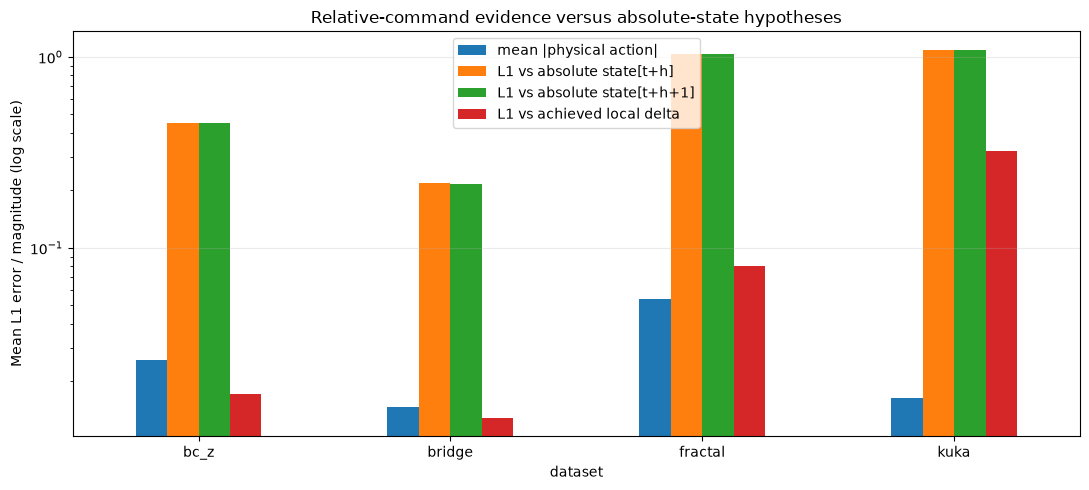

In [6]:
ax = results[[
    'mean |physical action|',
    'L1 vs absolute state[t+h]',
    'L1 vs absolute state[t+h+1]',
    'L1 vs achieved local delta',
]].plot.bar(figsize=(11, 5), logy=True)
ax.set_ylabel('Mean L1 error / magnitude (log scale)')
ax.set_title('Relative-command evidence versus absolute-state hypotheses')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Decision

**`cached-dataset/part_3` contains normalized relative controller commands, not absolute target states.**

More precisely:

1. The cache was generated with the default `action_target_mode=delta` and `normalize_actions=true`.
2. Bridge and BC-Z store Cartesian/rotation residuals; Kuka and Fractal store commanded relative end-effector translation/rotation.
3. `actions[t, h]` is the normalized command belonging to future episode step `t+h`. It is **not** an absolute pose and is **not** a cumulative displacement from `state[t]`.
4. The physical command may differ from `state[t+h+1] - state[t+h]` because the latter is achieved motion after controller and simulator dynamics. This is expected, particularly for Kuka and Fractal rotations.
5. Pose dimensions are q01/q99-normalized to `[-1, 1]`. The seventh dimension is the dataset-standardized binary gripper command/state and should be audited separately from continuous pose errors.

### Consequence for B0 retraining

Do not train this cache as `absolute_target_state`. Either configure the action model and rollout for normalized relative-delta commands, including per-dataset denormalization at inference, or explicitly materialize a new absolute-target-state cache from sequential states. Mixing this cache with an absolute-state rollout conversion creates a target/serving mismatch even when the training loss converges.